# LeetCode #852: Peak Index in a Mountain Array

https://leetcode.com/problems/peak-index-in-a-mountain-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan until `arr[i] > arr[i+1]` — the first descent marks the peak. Simple but $O(n)$.

### Optimal: Binary Search ★
At any midpoint: if `arr[mid] < arr[mid+1]`, the peak is to the right (ascending slope); otherwise the peak is at `mid` or to the left. Use `lo < hi` with `hi = mid` when descending. When the loop ends, `lo == hi == peak index`.

**Why this is better than Brute Force:** $O(\log n)$ vs $O(n)$ — the mountain guarantee means the array is unimodal, and binary search exploits this.

**Constraints:**
* 3 <= arr.length <= 10^5
* arr is guaranteed to be a mountain array
* arr[0] < arr[1] < … < arr[peak] > … > arr[n-1]

## Solutions

### C#

In [ ]:
public class Solution {
    public int PeakIndexInMountainArray(int[] arr) {
        int lo = 0, hi = arr.Length - 1;
        while (lo < hi) {
            int mid = lo + (hi - lo) / 2;
            // Ascending slope: peak is to the right
            if (arr[mid] < arr[mid + 1]) lo = mid + 1;
            else hi = mid;
        }
        // lo == hi == peak index
        return lo;
    }
}

### Python

In [ ]:
class Solution:
    def peakIndexInMountainArray(self, arr: list[int]) -> int:
        lo, hi = 0, len(arr) - 1
        while lo < hi:
            mid = lo + (hi - lo) // 2
            # Ascending slope: peak is to the right
            if arr[mid] < arr[mid + 1]:
                lo = mid + 1
            else:
                hi = mid
        # lo == hi == peak index
        return lo

### Go

In [ ]:
func peakIndexInMountainArray(arr []int) int {
    lo, hi := 0, len(arr)-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Ascending slope: peak is to the right
        if arr[mid] < arr[mid+1] {
            lo = mid + 1
        } else {
            hi = mid
        }
    }
    // lo == hi == peak index
    return lo
}

### Rust

In [ ]:
impl Solution {
    pub fn peak_index_in_mountain_array(arr: Vec<i32>) -> i32 {
        let (mut lo, mut hi) = (0usize, arr.len() - 1);
        while lo < hi {
            let mid = lo + (hi - lo) / 2;
            // Ascending slope: peak is to the right
            if arr[mid] < arr[mid + 1] {
                lo = mid + 1;
            } else {
                hi = mid;
            }
        }
        // lo == hi == peak index
        lo as i32
    }
}

## Example Scenarios

**1. Common Case**
**Input:** arr=[0,1,0]
lo=0,hi=2 → mid=1, arr[1]=1 < arr[2]=0? No → hi=1. mid=0, arr[0]=0 < arr[1]=1? Yes → lo=1. lo==hi=1 → return 1.

**2. Slightly Complex**
**Input:** arr=[0,2,1,0]
lo=0,hi=3 → mid=1, arr[1]=2 > arr[2]=1 → hi=1. mid=0, arr[0]=0 < arr[1]=2 → lo=1. lo==hi=1 → return 1.

**3. Edge Case: Time Factor**
**Input:** arr=[0,1,2,…,n-2,n-1,n-2,…,0] (peak at center, n=10^5)
Binary search hones in on n/2 in $\lfloor \log_2 n \rfloor = 16$ steps. Each step checks arr[mid] vs arr[mid+1] — one comparison per iteration. Linear scan would make $n/2 = 50000$ comparisons.

**4. Edge Case: Space Factor**
**Input:** arr=[0,1,0] (minimum length mountain)
O(1) extra space: only lo, hi, mid. Works correctly for n=3 — the minimum valid mountain array. Loop runs once.

**5. Almost-Impossible but Plausible**
**Input:** arr=[0,1,2,…,10^5−1] with peak at index 10^5−2 (near the right end, then one drop)
e.g., arr=[0,1,2,…,99998,99999,99998]. Every step: arr[mid]<arr[mid+1] → lo=mid+1 (ascending). lo advances rightward until reaching 99999. Returns index 99999. Maximum number of lo-advancing steps.

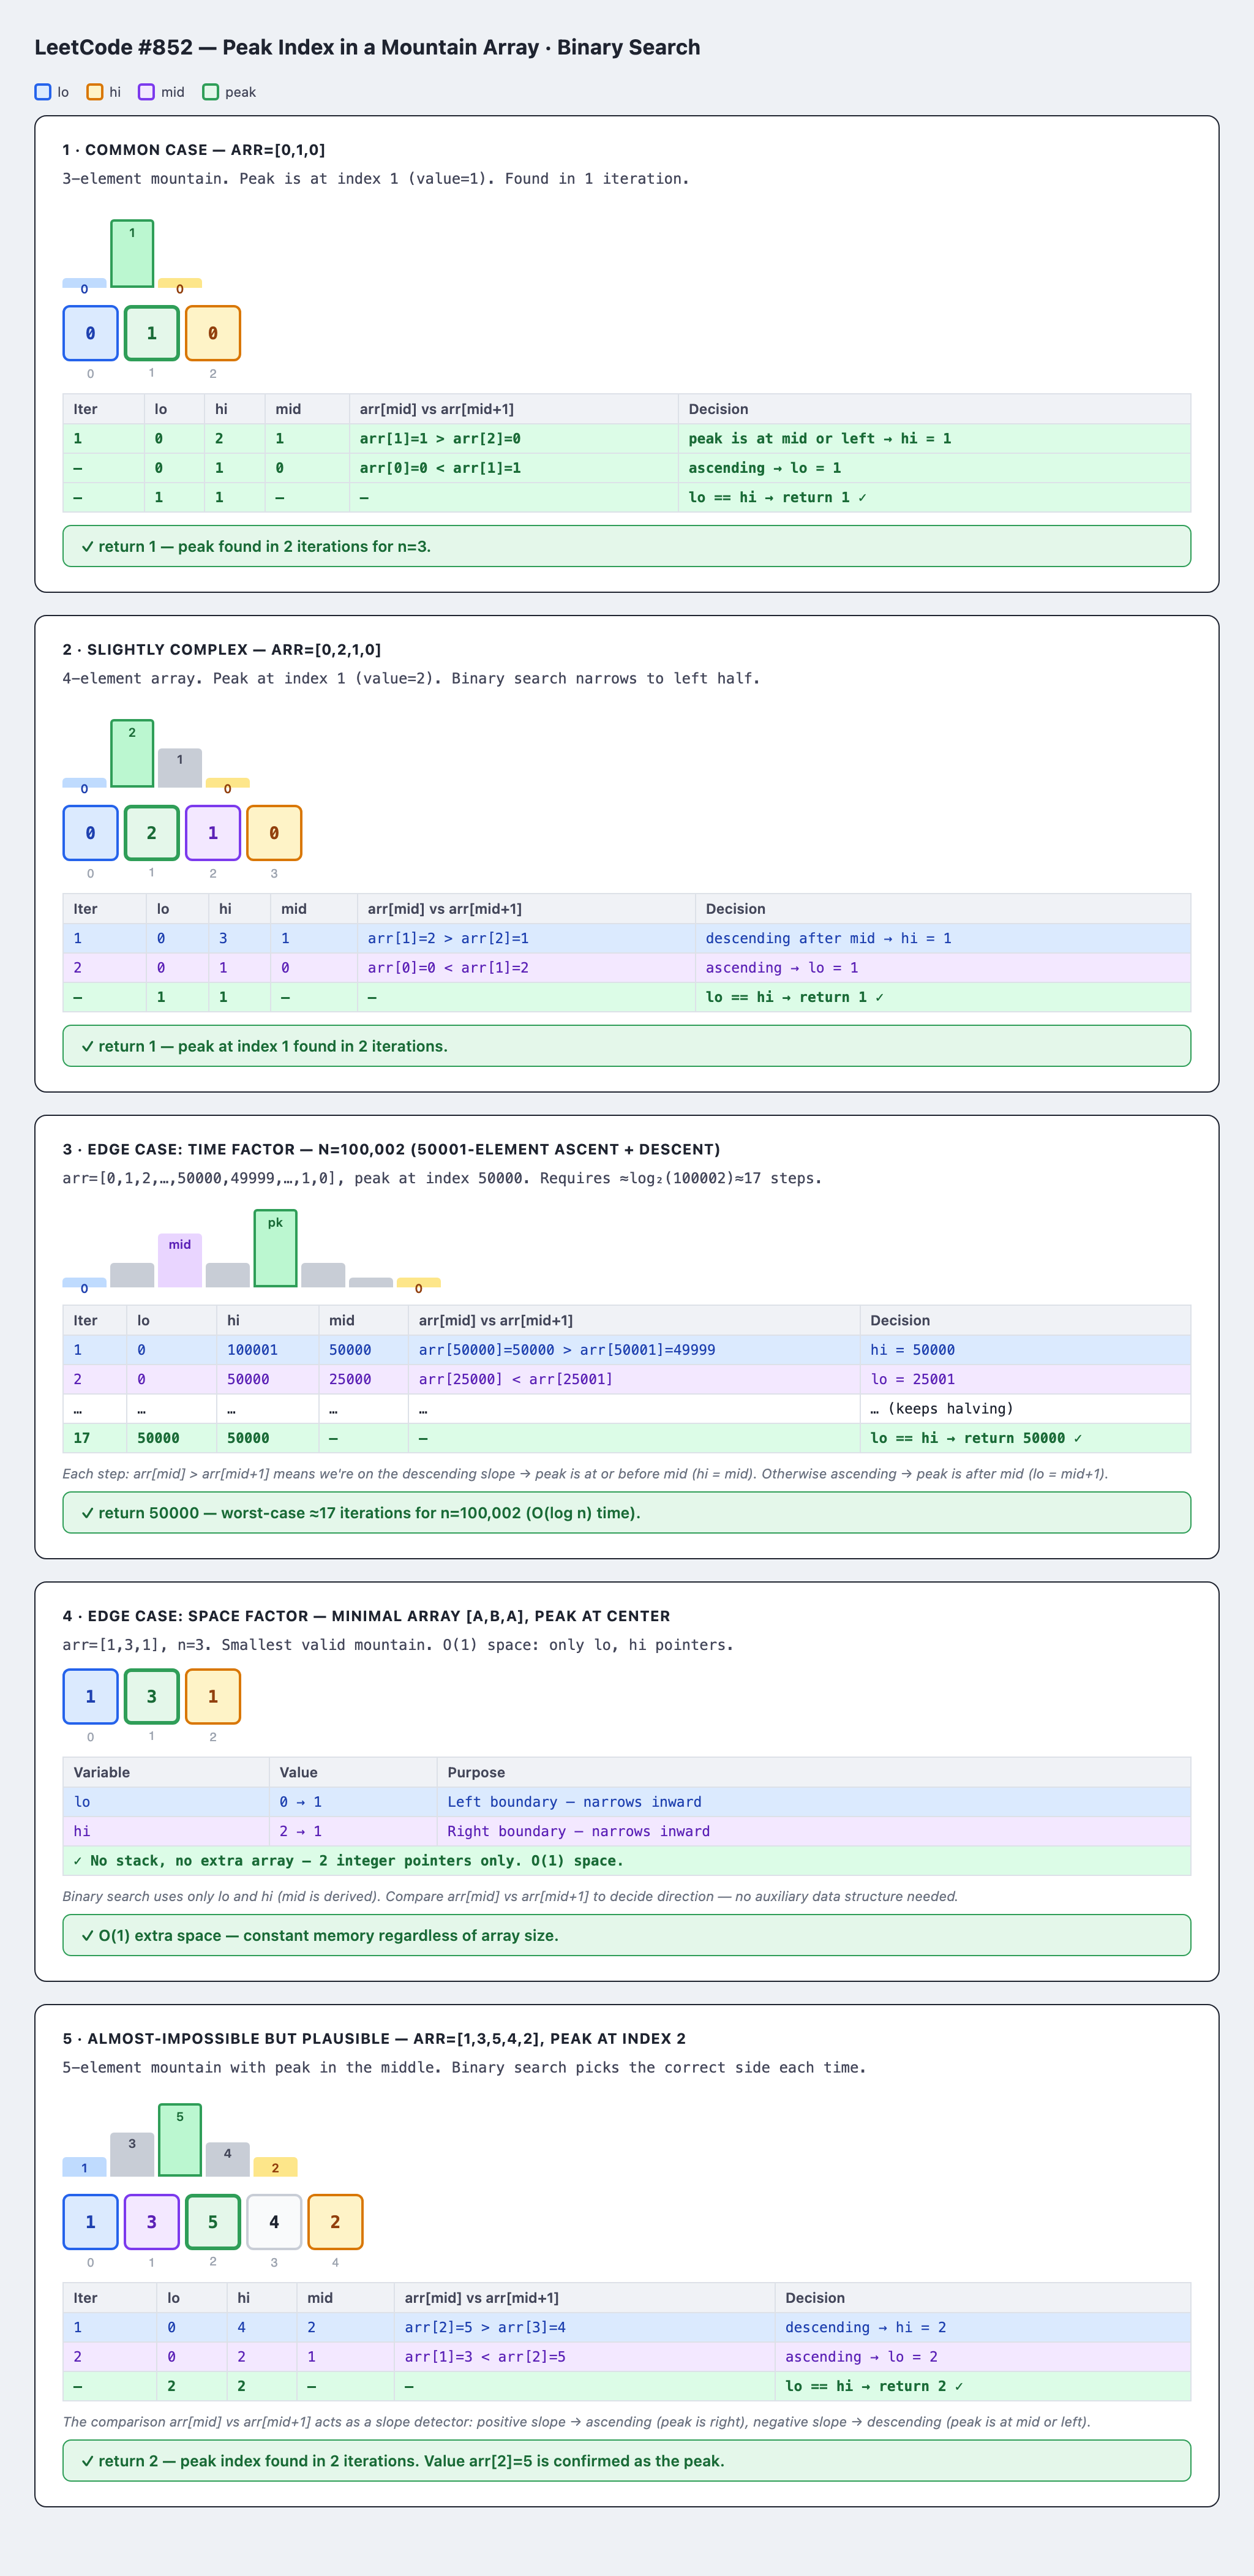